In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import requests

from io import StringIO

from UniversoActivos import UniversoActivosEstatico, UniversoActivosDinamico
from ProveedorDatos import YFinanceProvider
from VariablesTransformation import FeatureEngineer
import Modelos
Modelos = importlib.reload(Modelos)
from Modelos import *
import Estrategia
importlib.reload(Estrategia)
from Estrategia import *
import Backtest
importlib.reload(Backtest)
from Backtest import *
import auxiliary_functions as af
importlib.reload(af)


<module 'auxiliary_functions' from 'c:\\Users\\Deportivo Estadio\\Desktop\\Master Quant\\Gestión de activos\\Trabajo gestión cuantitativa\\Trabajo_gestion_cuantitativa\\Trabajo_gestion_cuantitativa\\auxiliary_functions.py'>

### Descarga de tickers actuales del STOXX50

In [3]:
def get_eurostoxx50_tickers():
    url = 'https://en.wikipedia.org/wiki/EURO_STOXX_50'
    headers = {"User-Agent": "Mozilla/5.0 ..."}
    response = requests.get(url, headers=headers, timeout=20)
    response.raise_for_status()

    tables = pd.read_html(StringIO(response.text), flavor='bs4')
    df = next(t for t in tables if 'Ticker' in t.columns)
    return df['Ticker'].tolist()

tickers = get_eurostoxx50_tickers()

# Simulaciones de la estrategia de los monos

In [4]:
start_date = "2024-03-01"
end_date = "2026-05-01"
nominal = 10000000

universo = UniversoActivosDinamico(
    tickers_actuales=tickers,
    start_date=start_date,
    end_date=end_date,
    csv_cambios_path=r"eurostoxx50_historico_cambios.csv"
)

proveedor = YFinanceProvider()

# Backtest monos
bt_random = BacktestRandom(
    universo=universo,
    proveedor=proveedor,
    start_date=start_date,
    end_date=end_date,
    nominal=nominal,
    n_activos=15,
    n_simulaciones_mc=1000,
)

res_random = bt_random.run_montecarlo(
    n_sims=5000,
    benchmark="^STOXX50E"
)

In [5]:
# Backtest real + monos con selección ML y pesos aleatorios

fe = FeatureEngineer(criterio=10, ticker_indice="^STOXX50E")
modelo = XGBoostModel(random_state=42, n_splits=3)

estrategia = EstrategiaMLMonteCarlo(
    modelo=modelo,
    n_activos_obj=15,
    umbral_salida=22,
    n_simulaciones=1000,   # Montecarlo interno de la estrategia real
    peso_min=0.02,
    peso_max=0.15,
)

bt_real = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=6,
    nominal=nominal,
)

serie_real, df_monos_ml_random = bt_real.run_con_monos_pesos(
    n_monos=5000,
    peso_min=0.02,
    peso_max=0.15,
    seed=42,
)

serie_real.name = "Estrategia real"

[Train] 2020-02-21 → 2024-02-16 | AUC=0.5326 | {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150, 'scale_pos_weight': 3, 'subsample': 0.7}
2024-03-01 | VP real=9,995,003 | activos=['AD.AS', 'ADS.DE', 'AIR.PA', 'ASML.AS', 'BAYN.DE', 'BNP.PA', 'ENEL.MI', 'IFX.DE', 'ISP.MI', 'MC.PA', 'PRX.AS', 'RHM.DE', 'RI.PA', 'SAN.MC', 'SAN.PA']
2024-03-08 | VP real=10,132,257 | activos=['ABI.BR', 'AD.AS', 'ADS.DE', 'BAYN.DE', 'BN.PA', 'BNP.PA', 'ENEL.MI', 'IFX.DE', 'INGA.AS', 'ISP.MI', 'MUV2.DE', 'PRX.AS', 'RHM.DE', 'RI.PA', 'SAN.PA']
2024-03-15 | VP real=10,377,531 | activos=['ADS.DE', 'ASML.AS', 'BAYN.DE', 'BBVA.MC', 'BN.PA', 'BNP.PA', 'IBE.MC', 'IFX.DE', 'INGA.AS', 'ITX.MC', 'MC.PA', 'PRX.AS', 'RHM.DE', 'SAN.PA', 'UCG.MI']
2024-03-22 | VP real=10,693,023 | activos=['ADS.DE', 'ALV.DE', 'BAS.DE', 'BAYN.DE', 'DB1.DE', 'DHL.DE', 'IBE.MC', 'IFX.DE', 'INGA.AS', 'PRX.AS', 'RACE.MI', 'RHM.DE', 'SAN.PA', 'TTE.PA', 'UCG.MI']
2024-03-29 | VP real=10,959,547 | activos=['ALV.DE

In [6]:
res_monos = af.resumen_backtest_monos(
    serie_real=serie_real,
    res_random=res_random,
    df_ml_random=df_monos_ml_random,
    rf_annual=0.0,
    pkl_path="Backtest_series/backtest_monos.pkl"
)

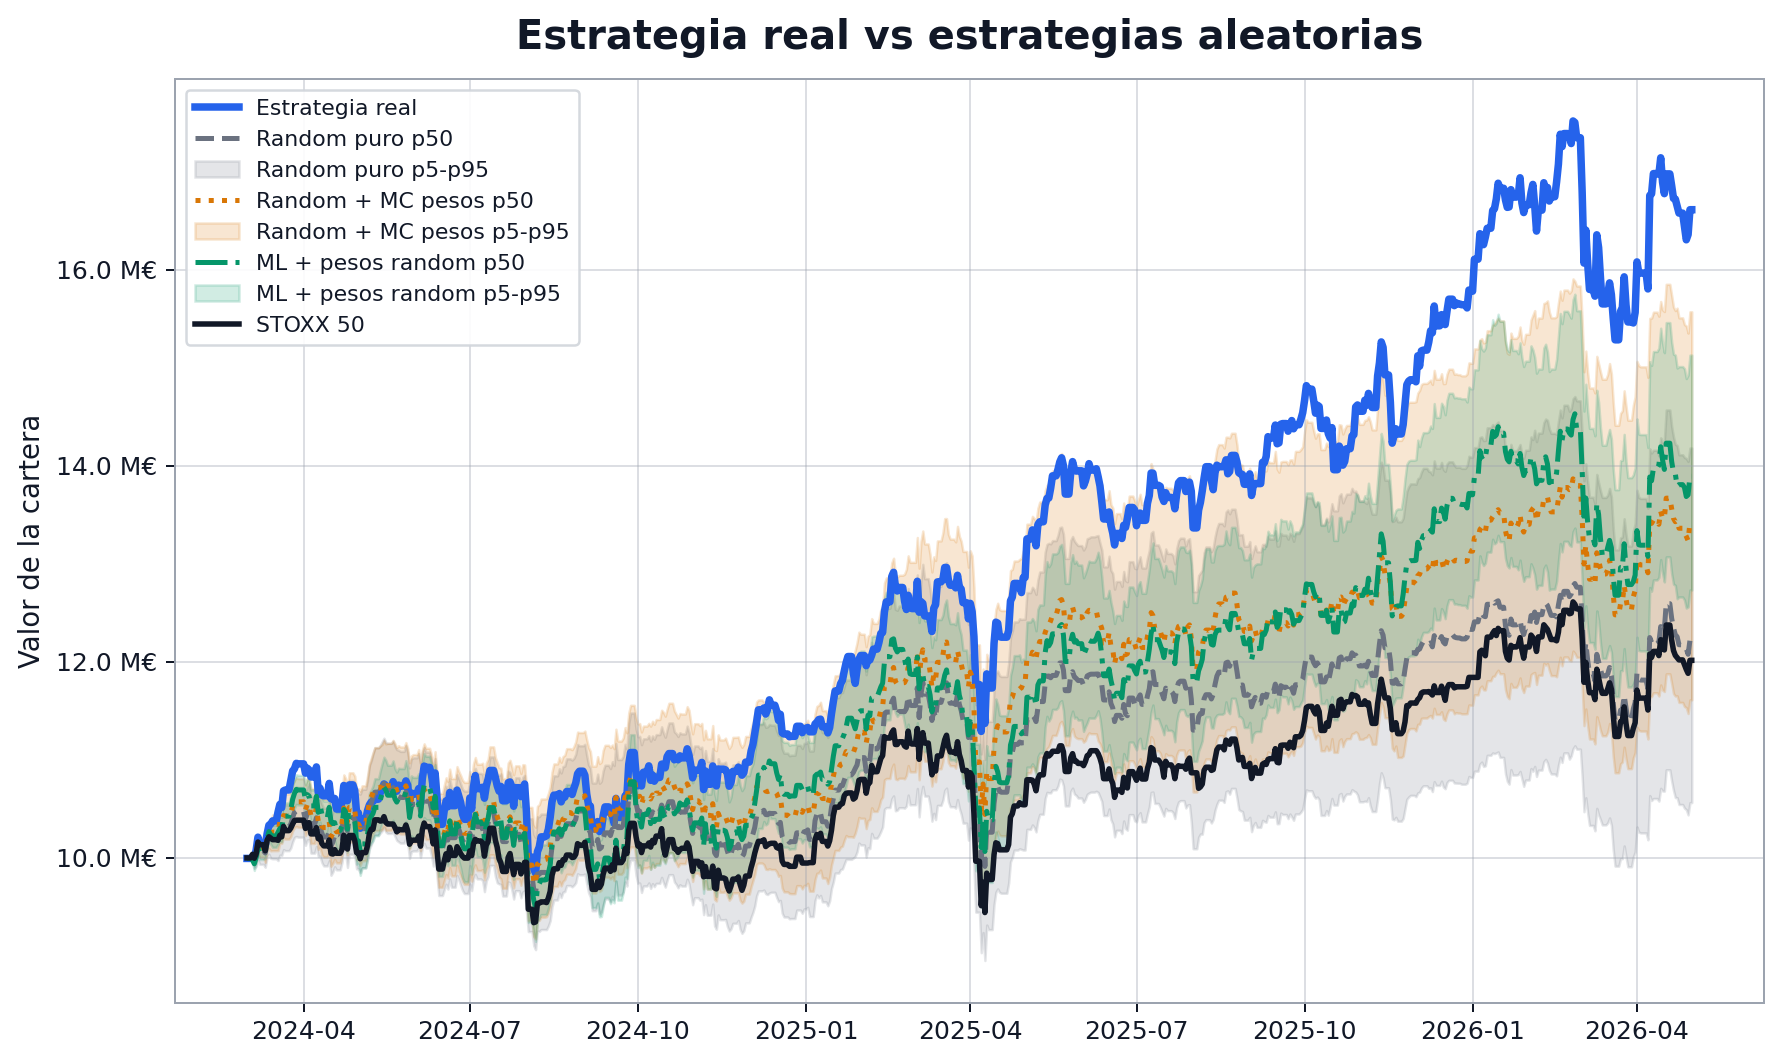

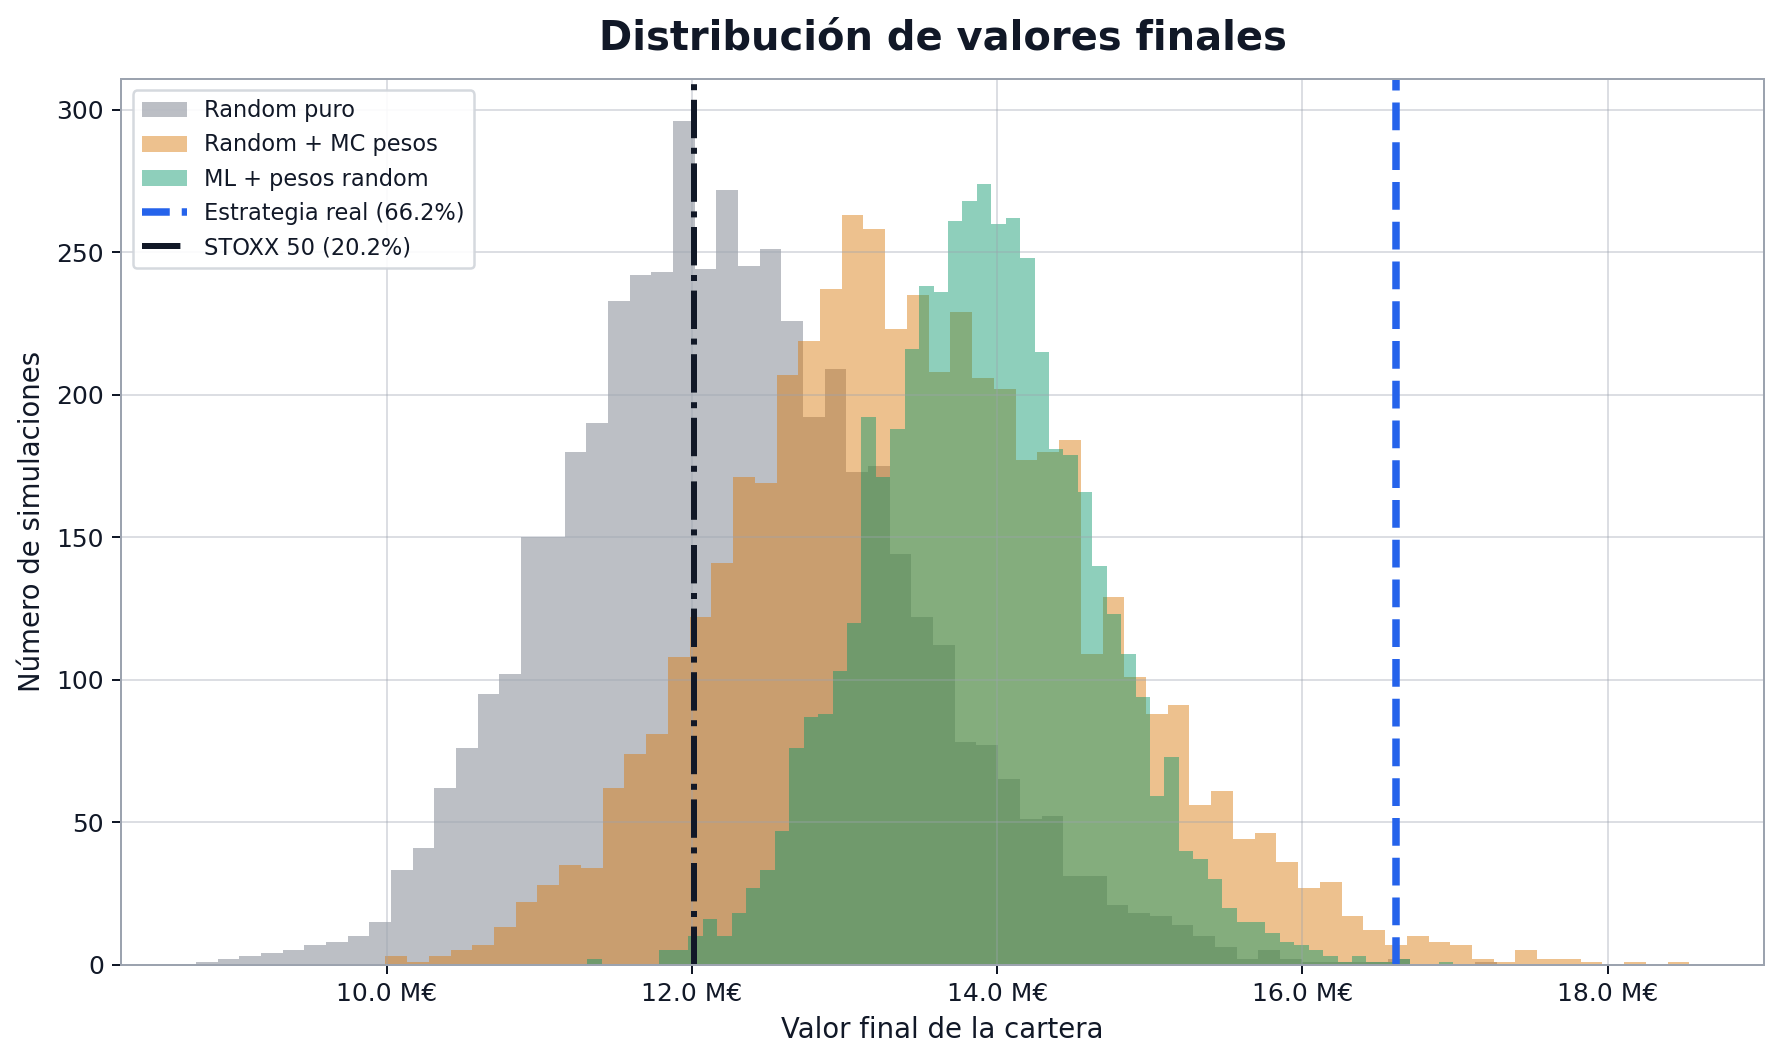

(<Figure size 1800x1080 with 1 Axes>,
 <Axes: title={'center': 'Distribución de valores finales'}, xlabel='Valor final de la cartera', ylabel='Número de simulaciones'>)

In [7]:
res_monos = pd.read_pickle("Backtest_series/backtest_monos.pkl")
af.grafico_monos_percentiles(res_monos, tema="blanco")
af.grafico_monos_histograma(res_monos, tema="blanco")

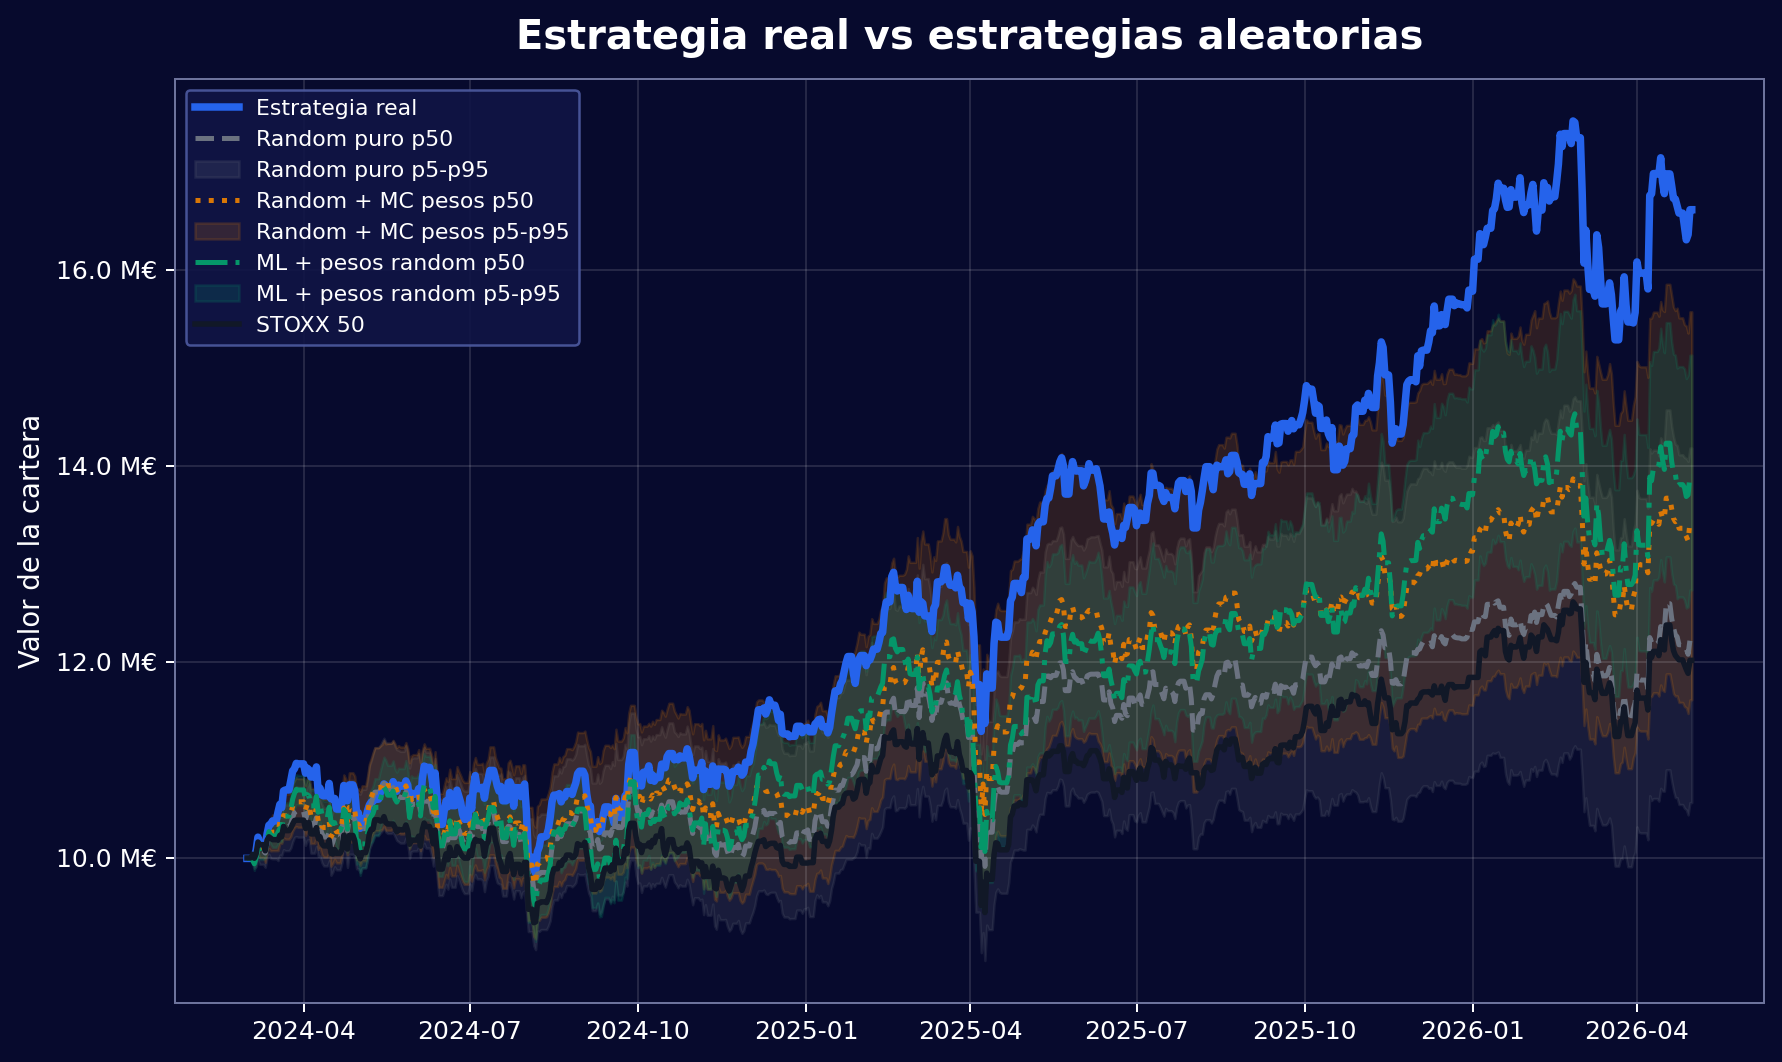

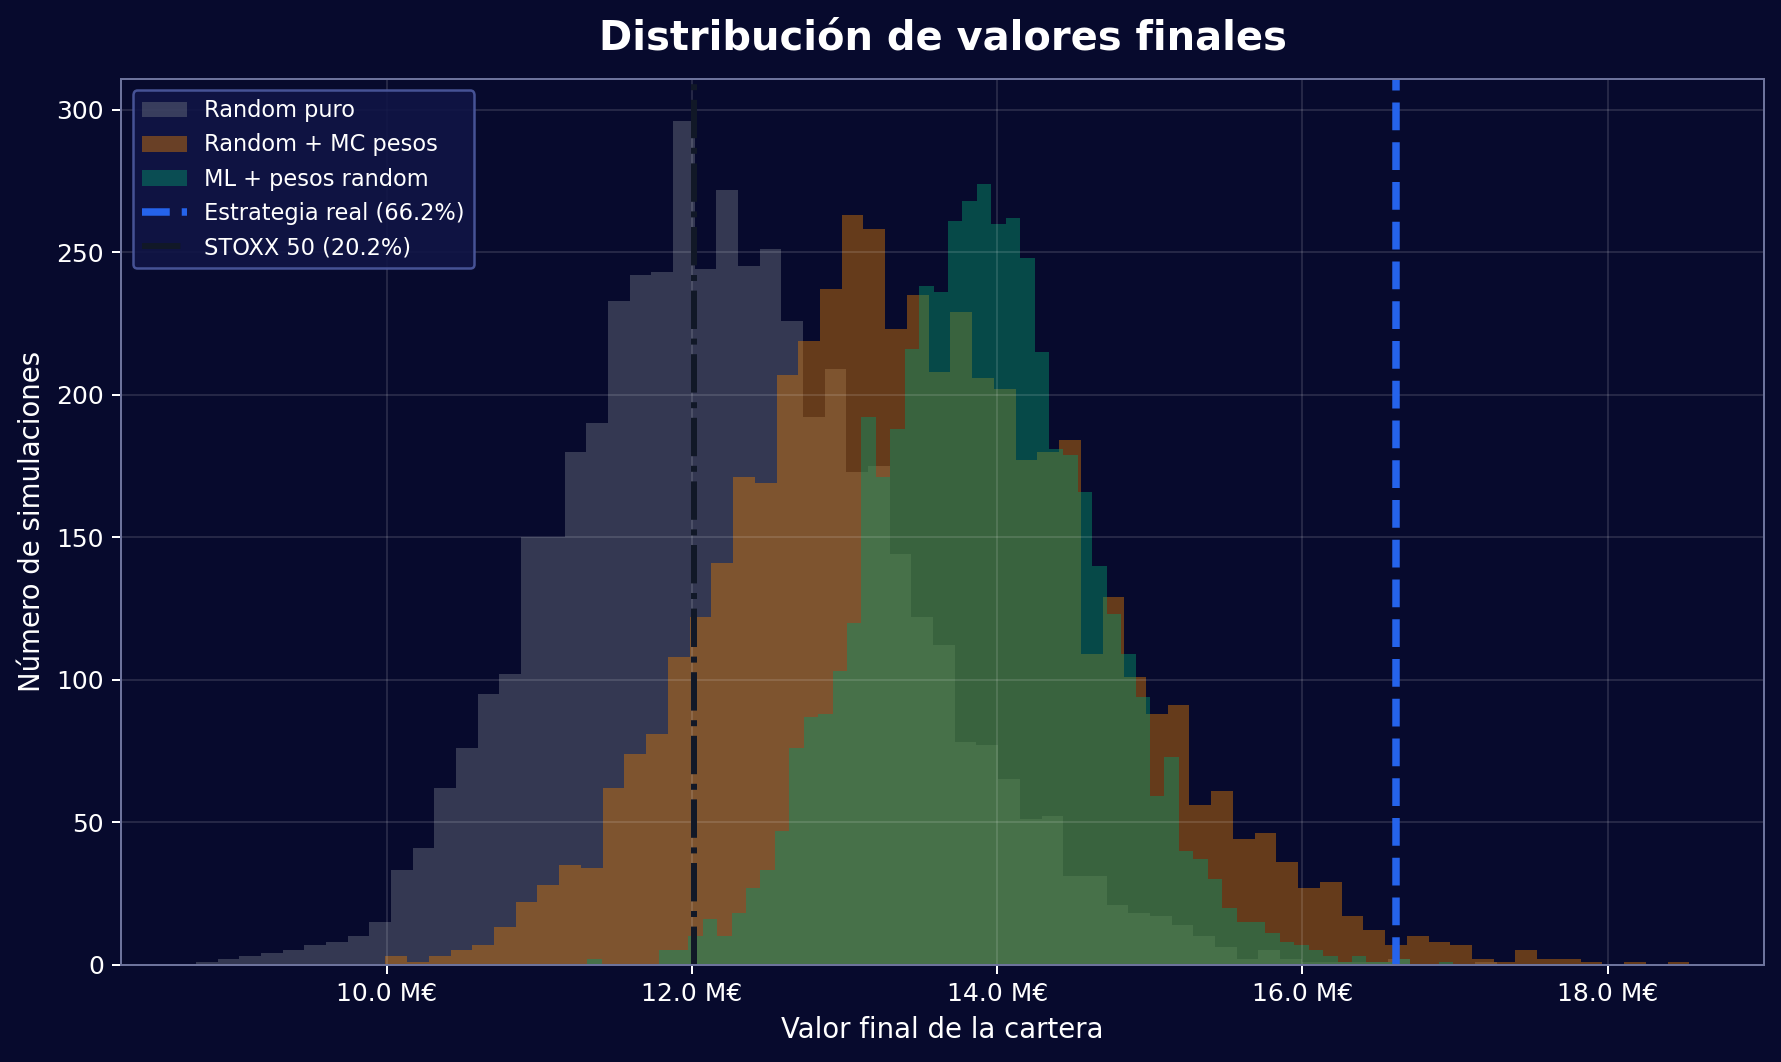

(<Figure size 1800x1080 with 1 Axes>,
 <Axes: title={'center': 'Distribución de valores finales'}, xlabel='Valor final de la cartera', ylabel='Número de simulaciones'>)

In [9]:
af.grafico_monos_percentiles(res_monos, tema="oscuro")
af.grafico_monos_histograma(res_monos, tema="oscuro")

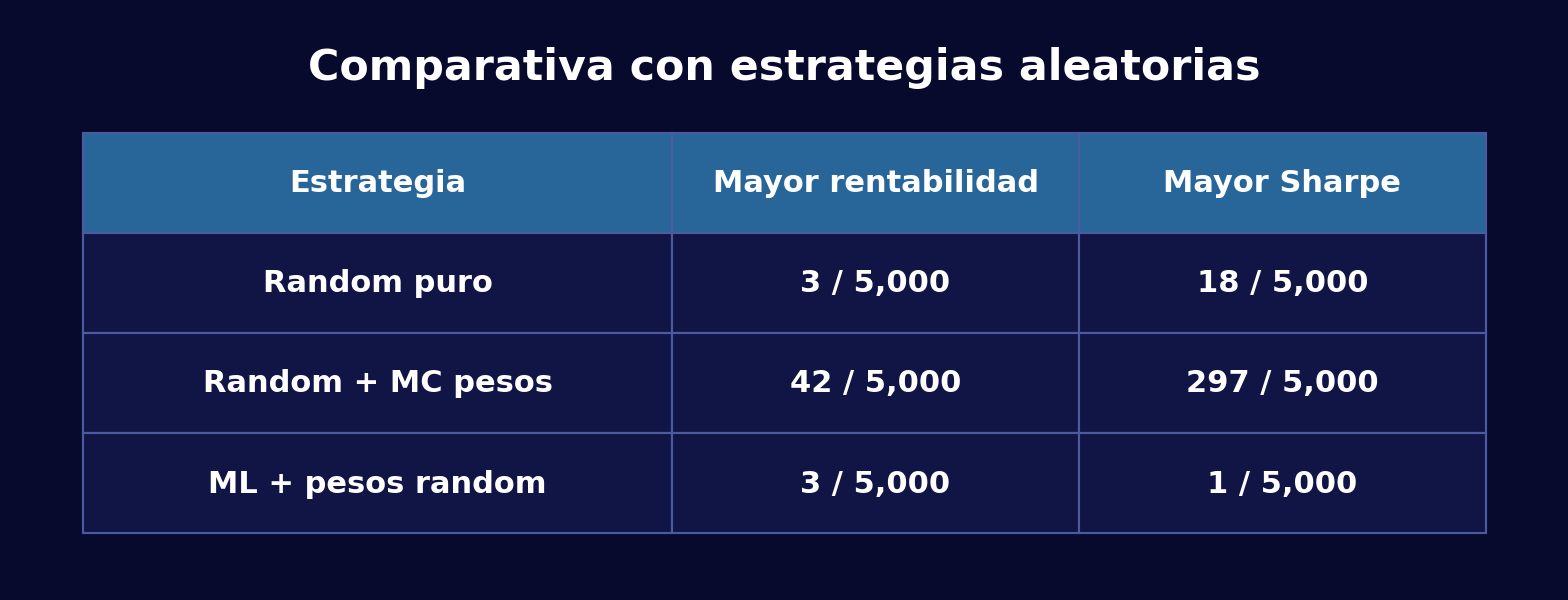

In [14]:
fig, ax = af.formatear_tabla_monos(
    res_monos["tabla"],
    tema="oscuro",
    titulo="Comparativa con estrategias aleatorias"
)

# Backtest corto plazo

In [10]:
import sys
sys.path.append("Monitoring")

import auxfun as mon

fecha_fin = "2026-05-14"
nominal = 10_000_000
path_real = r"Envios\historico_operativa.xlsx"

universo_tickers = mon.get_eurostoxx50_tickers()

hist = mon.historico_valor_cartera(
    path_real,
    fecha_fin,
    capital_inicial=nominal,
    hoja="Operativa",
    incluir_costes=True
)

hist.index = pd.to_datetime(hist.index).tz_localize(None)

serie_real_obs = (
    hist["Valor cartera"]
    .sort_index()
    .rename("Estrategia real")
)

start_date = serie_real_obs.index.min().strftime("%Y-%m-%d")
end_date = serie_real_obs.index.max().strftime("%Y-%m-%d")

c:\Users\Deportivo Estadio\Desktop\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\Trabajo_gestion_cuantitativa\Monitoring\auxfun.py:62: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  fecha_fin = pd.Timestamp.today().normalize() if fecha_fin is None else pd.to_datetime(fecha_fin, dayfirst=True).normalize()


In [7]:
universo = UniversoActivosDinamico(
    tickers_actuales=universo_tickers,
    start_date=start_date,
    end_date=end_date,
    csv_cambios_path=r"eurostoxx50_historico_cambios.csv"
)

bt_random = BacktestRandom(
    universo=universo,
    proveedor=YFinanceProvider(),
    start_date=start_date,
    end_date=end_date,
    nominal=nominal,
    n_activos=15,
    n_simulaciones_mc=1000,
)

res_random = bt_random.run_montecarlo(
    n_sims=5000,
    benchmark="^STOXX50E"
)

In [12]:
fe = FeatureEngineer(criterio=10, ticker_indice="^STOXX50E")
modelo = XGBoostModel(random_state=42, n_splits=3)

estrategia = EstrategiaMLMonteCarlo(
    modelo=modelo,
    n_activos_obj=15,
    umbral_salida=22,
    n_simulaciones=1000,
    peso_min=0.02,
    peso_max=0.15,
)

bt_ml_random = BacktestEngine(
    universo=universo,
    proveedor=YFinanceProvider(),
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=6,
    nominal=nominal,
)

_, df_monos_ml_random = bt_ml_random.run_con_monos_pesos(
    n_monos=5000,
    peso_min=0.02,
    peso_max=0.15,
    seed=42,
)

[Train] 2020-02-28 → 2026-02-27 | AUC=0.5444 | {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150, 'scale_pos_weight': 3, 'subsample': 0.7}
2026-03-13 | VP real=9,995,004 | activos=['ADYEN.AS', 'ARGX.BR', 'ASML.AS', 'BAYN.DE', 'BBVA.MC', 'DB1.DE', 'ENI.MI', 'ENR.DE', 'IFX.DE', 'RHM.DE', 'RMS.PA', 'SAN.MC', 'TTE.PA', 'UCG.MI', 'WKL.AS']
2026-03-20 | VP real=9,883,113 | activos=['ADS.DE', 'ADYEN.AS', 'ARGX.BR', 'ASML.AS', 'BAYN.DE', 'BBVA.MC', 'DBK.DE', 'ENI.MI', 'ENR.DE', 'IFX.DE', 'ISP.MI', 'RHM.DE', 'SAN.MC', 'TTE.PA', 'UCG.MI']
2026-03-27 | VP real=9,997,381 | activos=['ADS.DE', 'ADYEN.AS', 'ARGX.BR', 'ASML.AS', 'BAYN.DE', 'BBVA.MC', 'DBK.DE', 'ENI.MI', 'ENR.DE', 'ISP.MI', 'RHM.DE', 'SAF.PA', 'SAN.MC', 'TTE.PA', 'UCG.MI']
2026-04-03 | VP real=10,351,272 | activos=['ADS.DE', 'ADYEN.AS', 'ASML.AS', 'BAYN.DE', 'BBVA.MC', 'DBK.DE', 'ENI.MI', 'ENR.DE', 'IFX.DE', 'ISP.MI', 'RHM.DE', 'SAF.PA', 'SAN.MC', 'TTE.PA', 'WKL.AS']
2026-04-10 | VP real=10,760,945 | 

In [19]:
fecha_inicio_comun = max(
    serie_real_obs.dropna().index.min(),
    res_random["pesos_random"]["todas"].dropna(how="all").index.min(),
    res_random["pesos_mc"]["todas"].dropna(how="all").index.min(),
    df_monos_ml_random.dropna(how="all").index.min()
)

serie_real_corto = serie_real_obs.loc[fecha_inicio_comun:]
df_ml_random_corto = df_monos_ml_random.loc[fecha_inicio_comun:]

res_random_corto = {
    **res_random,
    "pesos_random": {
        **res_random["pesos_random"],
        "todas": res_random["pesos_random"]["todas"].loc[fecha_inicio_comun:]
    },
    "pesos_mc": {
        **res_random["pesos_mc"],
        "todas": res_random["pesos_mc"]["todas"].loc[fecha_inicio_comun:]
    },
}

if res_random.get("benchmark") is not None:
    res_random_corto["benchmark"] = res_random["benchmark"].loc[fecha_inicio_comun:]

res_monos_corto = af.resumen_backtest_monos(
    serie_real=serie_real_corto,
    res_random=res_random_corto,
    df_ml_random=df_ml_random_corto,
    rf_annual=0.0,
    pkl_path="Backtest_series/backtest_monos_corto_real.pkl"
)

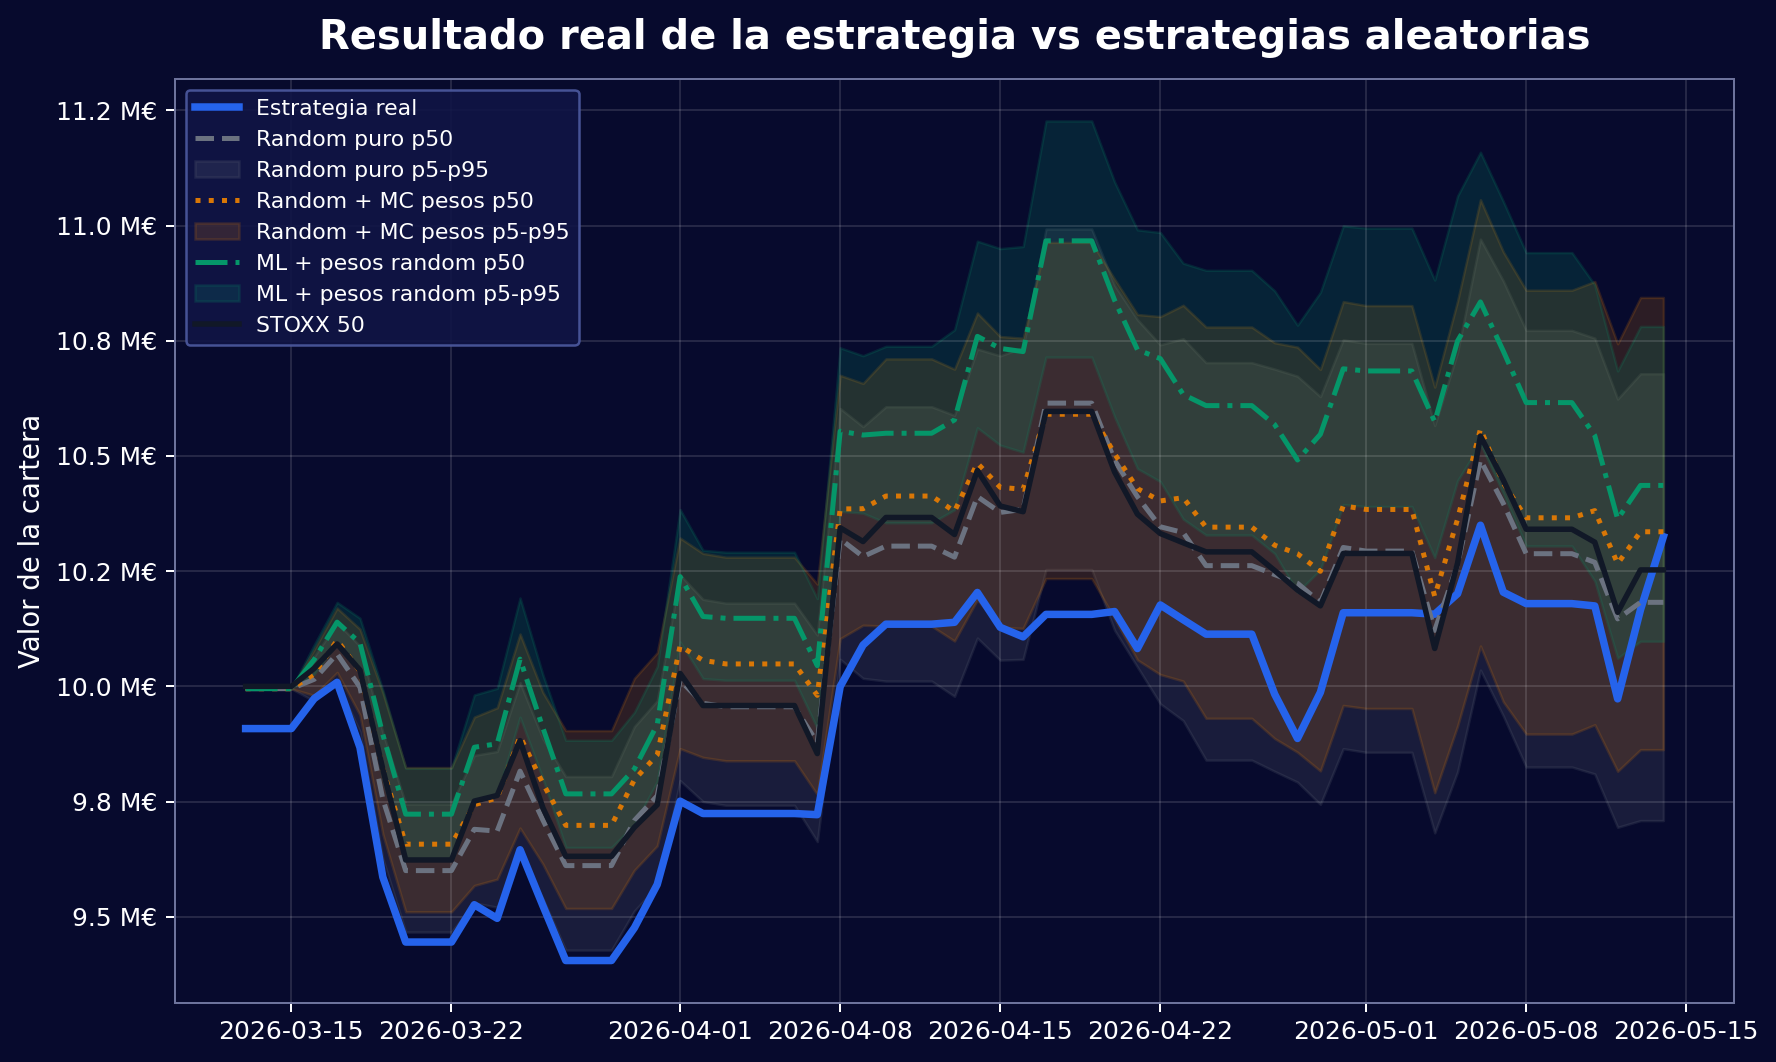

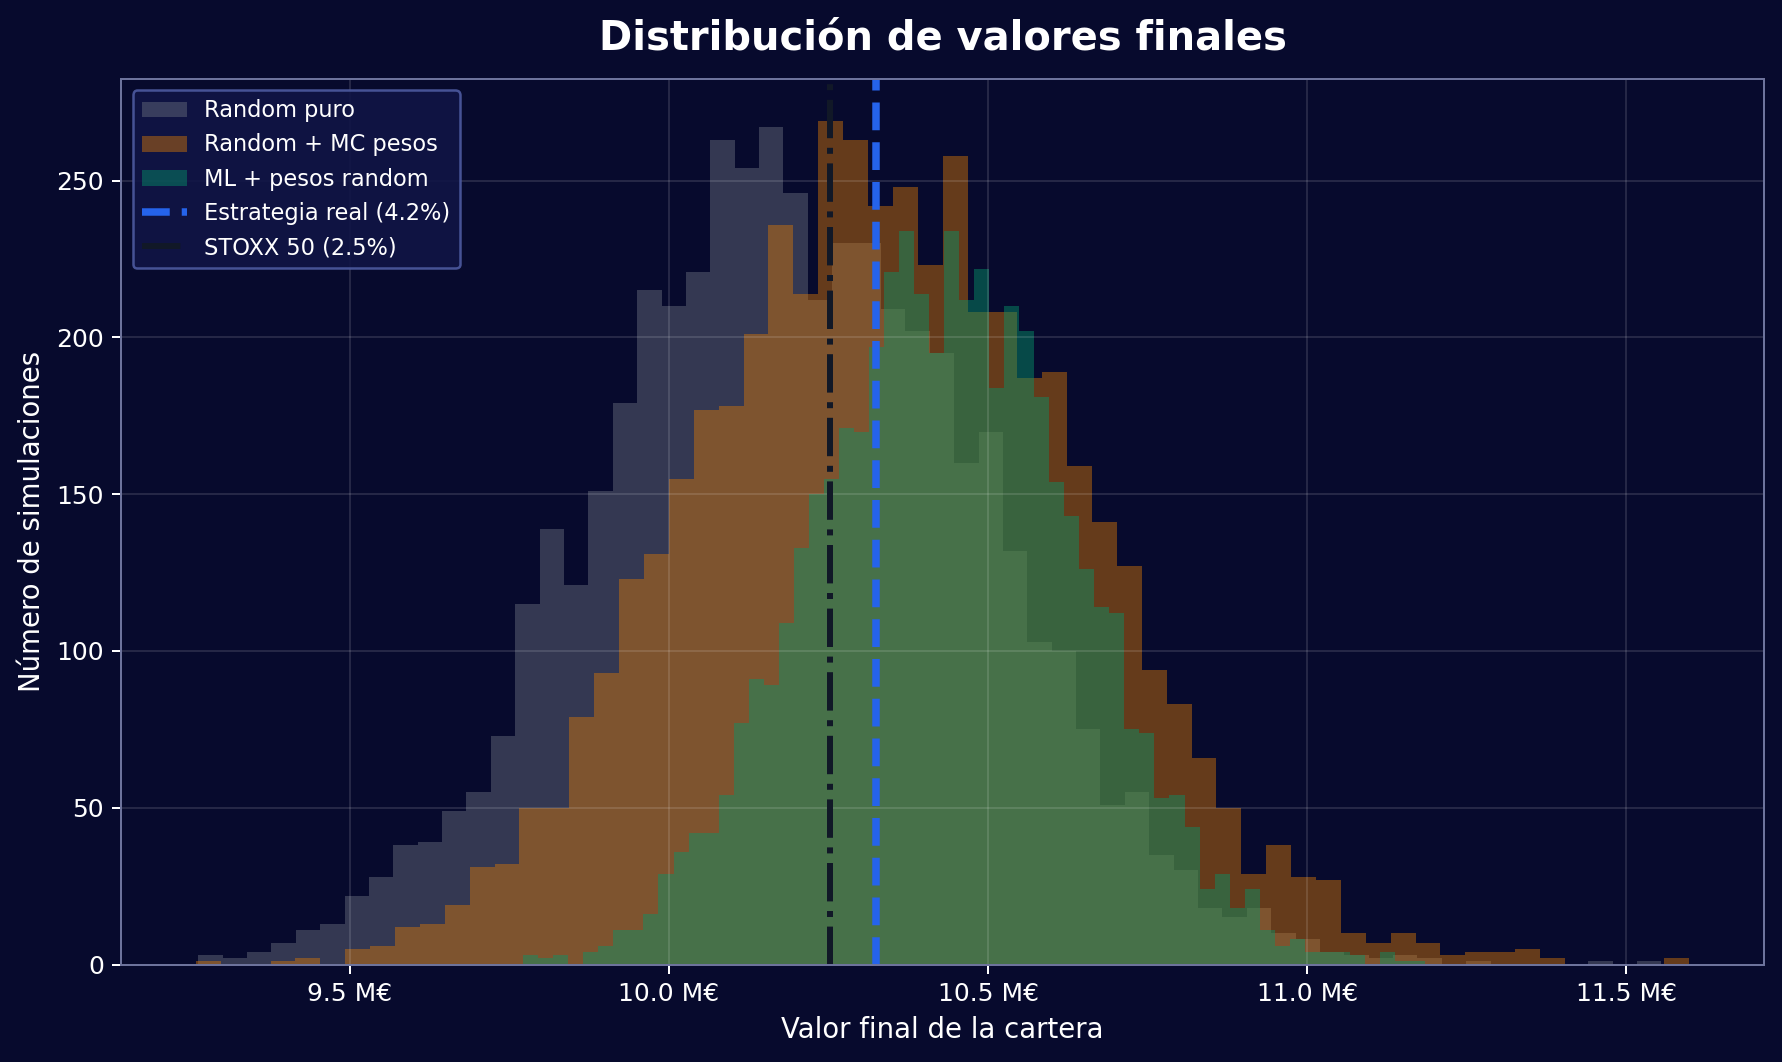

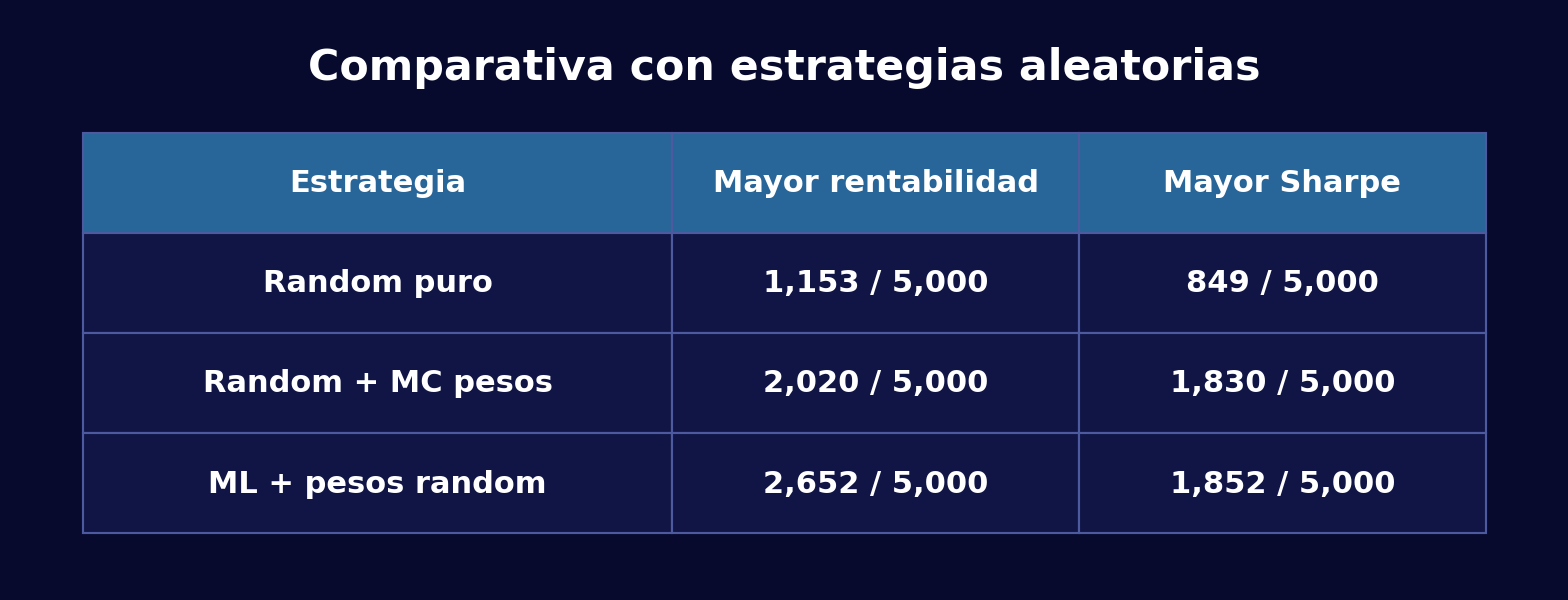

In [20]:
af.grafico_monos_percentiles(
    res_monos_corto,
    tema="oscuro",
    titulo="Resultado real de la estrategia vs estrategias aleatorias"
)

af.grafico_monos_histograma(
    res_monos_corto,
    tema="oscuro",
    titulo="Distribución de valores finales"
)

fig, ax = af.formatear_tabla_monos(
    res_monos_corto["tabla"],
    tema="oscuro",
    titulo="Comparativa con estrategias aleatorias"
)